# 2 Calibration Parameters Problem

In [1]:
from jax import config
config.update("jax_enable_x64", True)

# from data.dataloader import DataLoader
from kohgpjax.mappings import mapRto01, map01toR, mapRto0inf, map0inftoR
from jax import jit, grad

import jax.numpy as jnp
import gpjax as gpx
from kohgpjax.base import AbstractKOHModel

import numpy as np
import matplotlib.pyplot as plt

import mici
import arviz

from scipy.stats import gamma

from data.truefuncs import sin1_2 as truefunc

plot_style = {
    'mathtext.fontset': 'cm',
    'font.family': 'serif',
    'axes.titlesize': 10,
    'axes.labelsize': 10,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 8,
    'legend.frameon': False,
    'axes.linewidth': 0.5,
    'lines.linewidth': 0.5,
    'axes.labelpad': 2.,
    'figure.dpi': 150,
}

## The KOH Model

In [2]:
class Sin1_2(AbstractKOHModel):
    def k_eta(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.ProductKernel(
            kernels=[
                gpx.kernels.RBF( # x0
                    active_dims=[0],
                    lengthscale=jnp.array(ells[0]),
                    variance=jnp.array(1/lambdas[0])
                ), 
                gpx.kernels.RBF( # theta0
                    active_dims=[1],
                    lengthscale=jnp.array(ells[1]),
                ),
                gpx.kernels.RBF( # theta1
                    active_dims=[2],
                    lengthscale=jnp.array(ells[2]),
                )
            ]
        )
    
    def k_delta(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.RBF(
                active_dims=[0],
                lengthscale=jnp.array(ells[3]),
                variance=jnp.array(1/lambdas[1])
            )

    
    def k_epsilon(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.White(
                active_dims=[0],
                variance=jnp.array(1/lambdas[2])
            )
    
    def k_epsilon_eta(self, GPJAX_params) -> gpx.kernels.AbstractKernel:
        thetas, ells, lambdas = GPJAX_params
        return gpx.kernels.White(
                active_dims=[0],
                variance=jnp.array(1/lambdas[3])
            )


    def KOH_log_prior(
        self,
        GPJAX_params,
    ):
        thetas, ells, lambdas = GPJAX_params

        ####### ell #######
        # % Prior for ell_eta
        # % EXAMPLE: ell_eta_0 ~ GAM(4,1.4) where 2nd param is rate
        logprior = (4-1)*jnp.log(ells[0]) - 1.4*ells[0]
        # % Prior for ell_eta_1 ~ GAM(2,3.5) where 2nd param is rate
        logprior += (2-1)*jnp.log(ells[1]) - 3.5*ells[1]
        # % Prior for ell_eta_2 ~ GAM(2,2) where 2nd param is rate
        logprior += (2-1)*jnp.log(ells[2]) - 2*ells[2]
        # # % Prior for ell_delta_0 ~ GAM(4,2) where 2nd param is rate
        logprior += (4-1)*jnp.log(ells[3]) - 2*ells[3] # encourage smaller lengthscales on the discrepancy term


        ####### lambda #######
        # % Prior for lambda_eta
        # % EXAMPLE: lambda_eta ~ GAM(2,4) where 2nd param is rate
        # logprior += (2-1)*jnp.log(lambdas[0]) - 4*lambdas[0]
        # % EXAMPLE: lambda_eta ~ GAM(10,10) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[0]) - 10*lambdas[0]

        # % Prior for lambda_b
        # % EXAMPLE: lambda_b ~ GAM(2,0.1) where 2nd param is rate
        # logprior += (2-1)*jnp.log(lambdas[1]) - 0.1*lambdas[1]
        # % EXAMPLE: lambda_b ~ GAM(10,0.3) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[1]) - 0.3*lambdas[1]

        # % Prior for lambda_e
        # % EXAMPLE: lambda_e ~ GAM(12,0.025) where 2nd param is rate
        # logprior += (12-1)*jnp.log(lambdas[2]) - 0.025*lambdas[2]
        # % EXAMPLE: lambda_e ~ GAM(10,0.03) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[2]) - 0.03*lambdas[2]

        # % Prior for lambda_en
        # % EXAMPLE: lambda_en ~ GAM(10,0.001) where 2nd param is rate
        logprior += (10-1)*jnp.log(lambdas[3]) - 0.001*lambdas[3]

        return logprior

## Load data

In [3]:
class DataLoader:
    def __init__(
        self, 
        data_field_path: str = 'data/simple_field.csv', 
        data_comp_path: str = 'data/simple_comp.csv'
    ):
        DATAFIELD = np.loadtxt(data_field_path, delimiter=',', dtype=np.float32)
        DATACOMP = np.loadtxt(data_comp_path, delimiter=',', dtype=np.float32)

        self.yf = np.reshape(DATAFIELD[:, 0], (-1,1))
        self.yc = np.reshape(DATACOMP[:, 0], (-1,1))
        self.xf = np.reshape(DATAFIELD[:, 1], (-1, 1))
        self.xc = np.reshape(DATACOMP[:, 1], (-1,1))
        self.tc = np.reshape(DATACOMP[:, 2:], (-1,2))

        #Standardize full response using mean and std of yc
        self.yc_mean = np.mean(self.yc)

        self.t_min = np.min(self.tc, axis=0)
        self.t_max = np.max(self.tc, axis=0)

        self.yc_centered = self.yc - self.yc_mean
        self.yf_centered = self.yf - self.yc_mean

        self.tc_normalized = (self.tc - self.t_min)/(self.t_max - self.t_min)

        self.x_stack = jnp.vstack((self.xf, self.xc), dtype=np.float64)
        self.y = jnp.vstack((self.yf_centered, self.yc_centered), dtype=np.float64)

    def get_data(self):
        return self.x_stack, self.tc_normalized, self.y
        # return self.x_stack, self.tc, self.y

    def transform_y(self, y):
        return y - self.yc_mean

    def inverse_transform_y(self, y):
        return y + self.yc_mean

In [4]:
dataloader = DataLoader(
    'data/toy/field_sin1_2_simple_growing.csv', 
    'data/toy/sim_sin1_2_simple_growing.csv'
)
data = dataloader.get_data()
model = Sin1_2(*data)

tmax = dataloader.t_max
tmin = dataloader.t_min

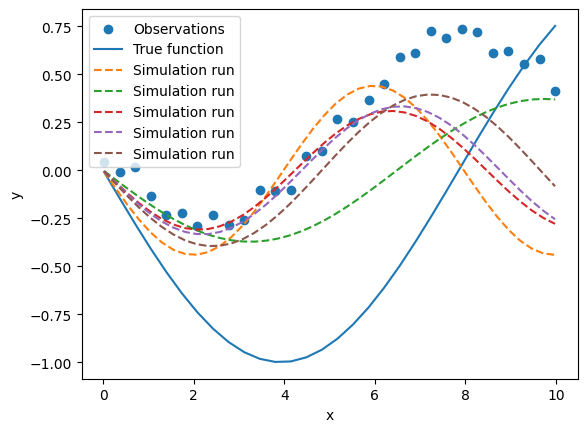

In [5]:
fig, ax = plt.subplots(1, 1)
ax.scatter(dataloader.xf, dataloader.yf, label='Observations')
ax.plot(dataloader.xf, truefunc(dataloader.xf), label='True function')
rng = np.random.default_rng()
ts = rng.permutation(np.unique(dataloader.tc[:,0]))[:5]
for t in ts:
    rows = dataloader.tc[:,0]==t
    ax.plot(dataloader.xc[rows], dataloader.yc[rows], '--', label=f'Simulation run')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
plt.show()

## MCMC Setup

In [6]:
theta_0 = 0.5
theta_1 = 0.25

# ell_eta_0_0 = 1 # np.sqrt(np.var(dataloader.xf))/3
# ell_eta_1_1 = 0.3
# ell_eta_1_2 = 0.3
# ell_delta_0_0 = 1 # np.sqrt(np.var(dataloader.xf))/5

ell_eta_0_0 = 2 # np.sqrt(np.var(dataloader.xf))/3
ell_eta_1_1 = 0.2
ell_eta_1_2 = 0.2
ell_delta_0_0 = 3 # np.sqrt(np.var(dataloader.xf))/5

lambda_eta_0 = 1
lambda_delta_0 = 30
lambda_epsilon_0 = 400
lambda_epsilon_eta_0 = 10000

init_state = np.array([
    map01toR(theta_0), 
    map01toR(theta_1),
    map0inftoR(ell_eta_0_0),
    map0inftoR(ell_eta_1_1),
    map0inftoR(ell_eta_1_2),
    map0inftoR(ell_delta_0_0),
    map0inftoR(lambda_eta_0),
    map0inftoR(lambda_delta_0),
    map0inftoR(lambda_epsilon_0),
    map0inftoR(lambda_epsilon_eta_0),
])

In [7]:
param_transform_mici_to_gpjax = lambda x: [
    [ # theta (calibration) parameters
        mapRto01(x[0]),
        mapRto01(x[1]),
        # mapRto01(x[2]),
    ],
    [ # lengthscale parameters
        mapRto0inf(x[2]), 
        mapRto0inf(x[3]), 
        mapRto0inf(x[4]),
        mapRto0inf(x[5]),
    ],
    [ # lambda (variance) parameters
        mapRto0inf(x[6]), 
        mapRto0inf(x[7]), 
        mapRto0inf(x[8]), 
        mapRto0inf(x[9]),
    ]
]

In [8]:
neg_log_posterior_density = model.get_KOH_neg_log_pos_dens_func(
    param_transform_mici_to_gpjax
)

system = mici.systems.EuclideanMetricSystem(
    neg_log_dens=neg_log_posterior_density,
    backend="jax"
)

integrator = mici.integrators.LeapfrogIntegrator(system)

## Running MCMC algorithm

In [9]:
seed = 1234
n_chain = 2
n_warm_up_iter = 500
n_main_iter = 500
rng = np.random.default_rng(seed)

##### Mici sampler and adapters #####
# sampler = mici.samplers.StaticMetropolisHMC(system, integrator, rng, n_step=1)
# sampler = mici.samplers.StaticMetropolisHMC(system, integrator, rng, n_step=3)
sampler = mici.samplers.DynamicMultinomialHMC(system, integrator, rng, max_tree_depth=5)
adapters = [
    mici.adapters.DualAveragingStepSizeAdapter(0.8),
    # mici.adapters.DualAveragingStepSizeAdapter(0.234),
    mici.adapters.OnlineCovarianceMetricAdapter()
]

def trace_func(state):
    return {
        'm_theta_0': state.pos[0], 
        'm_theta_1': state.pos[1],
        'm_ell_eta_0': state.pos[2], 
        'm_ell_eta_1': state.pos[3],
        'm_ell_eta_2': state.pos[4],
        'm_ell_delta_0': state.pos[5],
        'm_lambda_eta': state.pos[6],
        'm_lambda_delta': state.pos[7],
        'm_lambda_epsilon': state.pos[8],
        'm_lambda_epsilon_eta': state.pos[9],
        'hamiltonian': system.h(state)
    }

final_states, traces, stats = sampler.sample_chains(
    n_warm_up_iter, 
    n_main_iter, 
    [init_state] * n_chain, 
    adapters=adapters, 
    n_process=1, # only 1 works on MacOS
    trace_funcs=[trace_func],
    monitor_stats=("n_step", "accept_stat", "step_size", "diverging")
)

Sampling stage: Initial fast adaptive [17:01] > Slow adaptive (1/4) [05:55] > Slow adaptive (2/4) [08:08] > Slow adaptive (3/4) [13:31] > Slow adaptive (4/4) [25:47] > Final fast adaptive [09:36] > Main non-adaptive [1:18:14]

Chain 1/2: 100%|██████████|500/500 [42:00<00:00, 5.04s/it, n_step=17.6, accept_stat=0.968, step_size=0.259, diverging=0.0140]

Chain 2/2: 100%|██████████|500/500 [36:13<00:00, 4.35s/it, n_step=15.8, accept_stat=0.832, step_size=0.259, diverging=0.152]

## Analyse the raw MCMC chains

In [10]:
arviz.summary(traces)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
hamiltonian,-3851.803,3.110,-3857.228,-3846.081,0.156,0.090,382.0,676.0,1.01
m_ell_delta_0,1.208,0.285,0.664,1.724,0.010,0.008,874.0,732.0,1.00
m_ell_eta_0,1.123,0.040,1.047,1.193,0.001,0.001,1388.0,919.0,1.00
m_ell_eta_1,1.405,0.112,1.189,1.605,0.003,0.004,1656.0,634.0,1.00
m_ell_eta_2,-0.490,0.053,-0.590,-0.386,0.002,0.002,1291.0,489.0,1.00
m_lambda_delta,3.389,0.310,2.824,3.995,0.009,0.013,1145.0,482.0,1.00
m_lambda_epsilon,5.944,0.214,5.581,6.357,0.006,0.008,1558.0,740.0,1.01
m_lambda_epsilon_eta,12.789,0.051,12.680,12.873,0.002,0.002,976.0,705.0,1.00
m_lambda_eta,0.294,0.228,-0.117,0.726,0.006,0.007,1367.0,648.0,1.00
m_theta_0,-427437.106,300746.363,-852830.206,-80.146,142807.300,21418.298,5.0,82.0,1.32


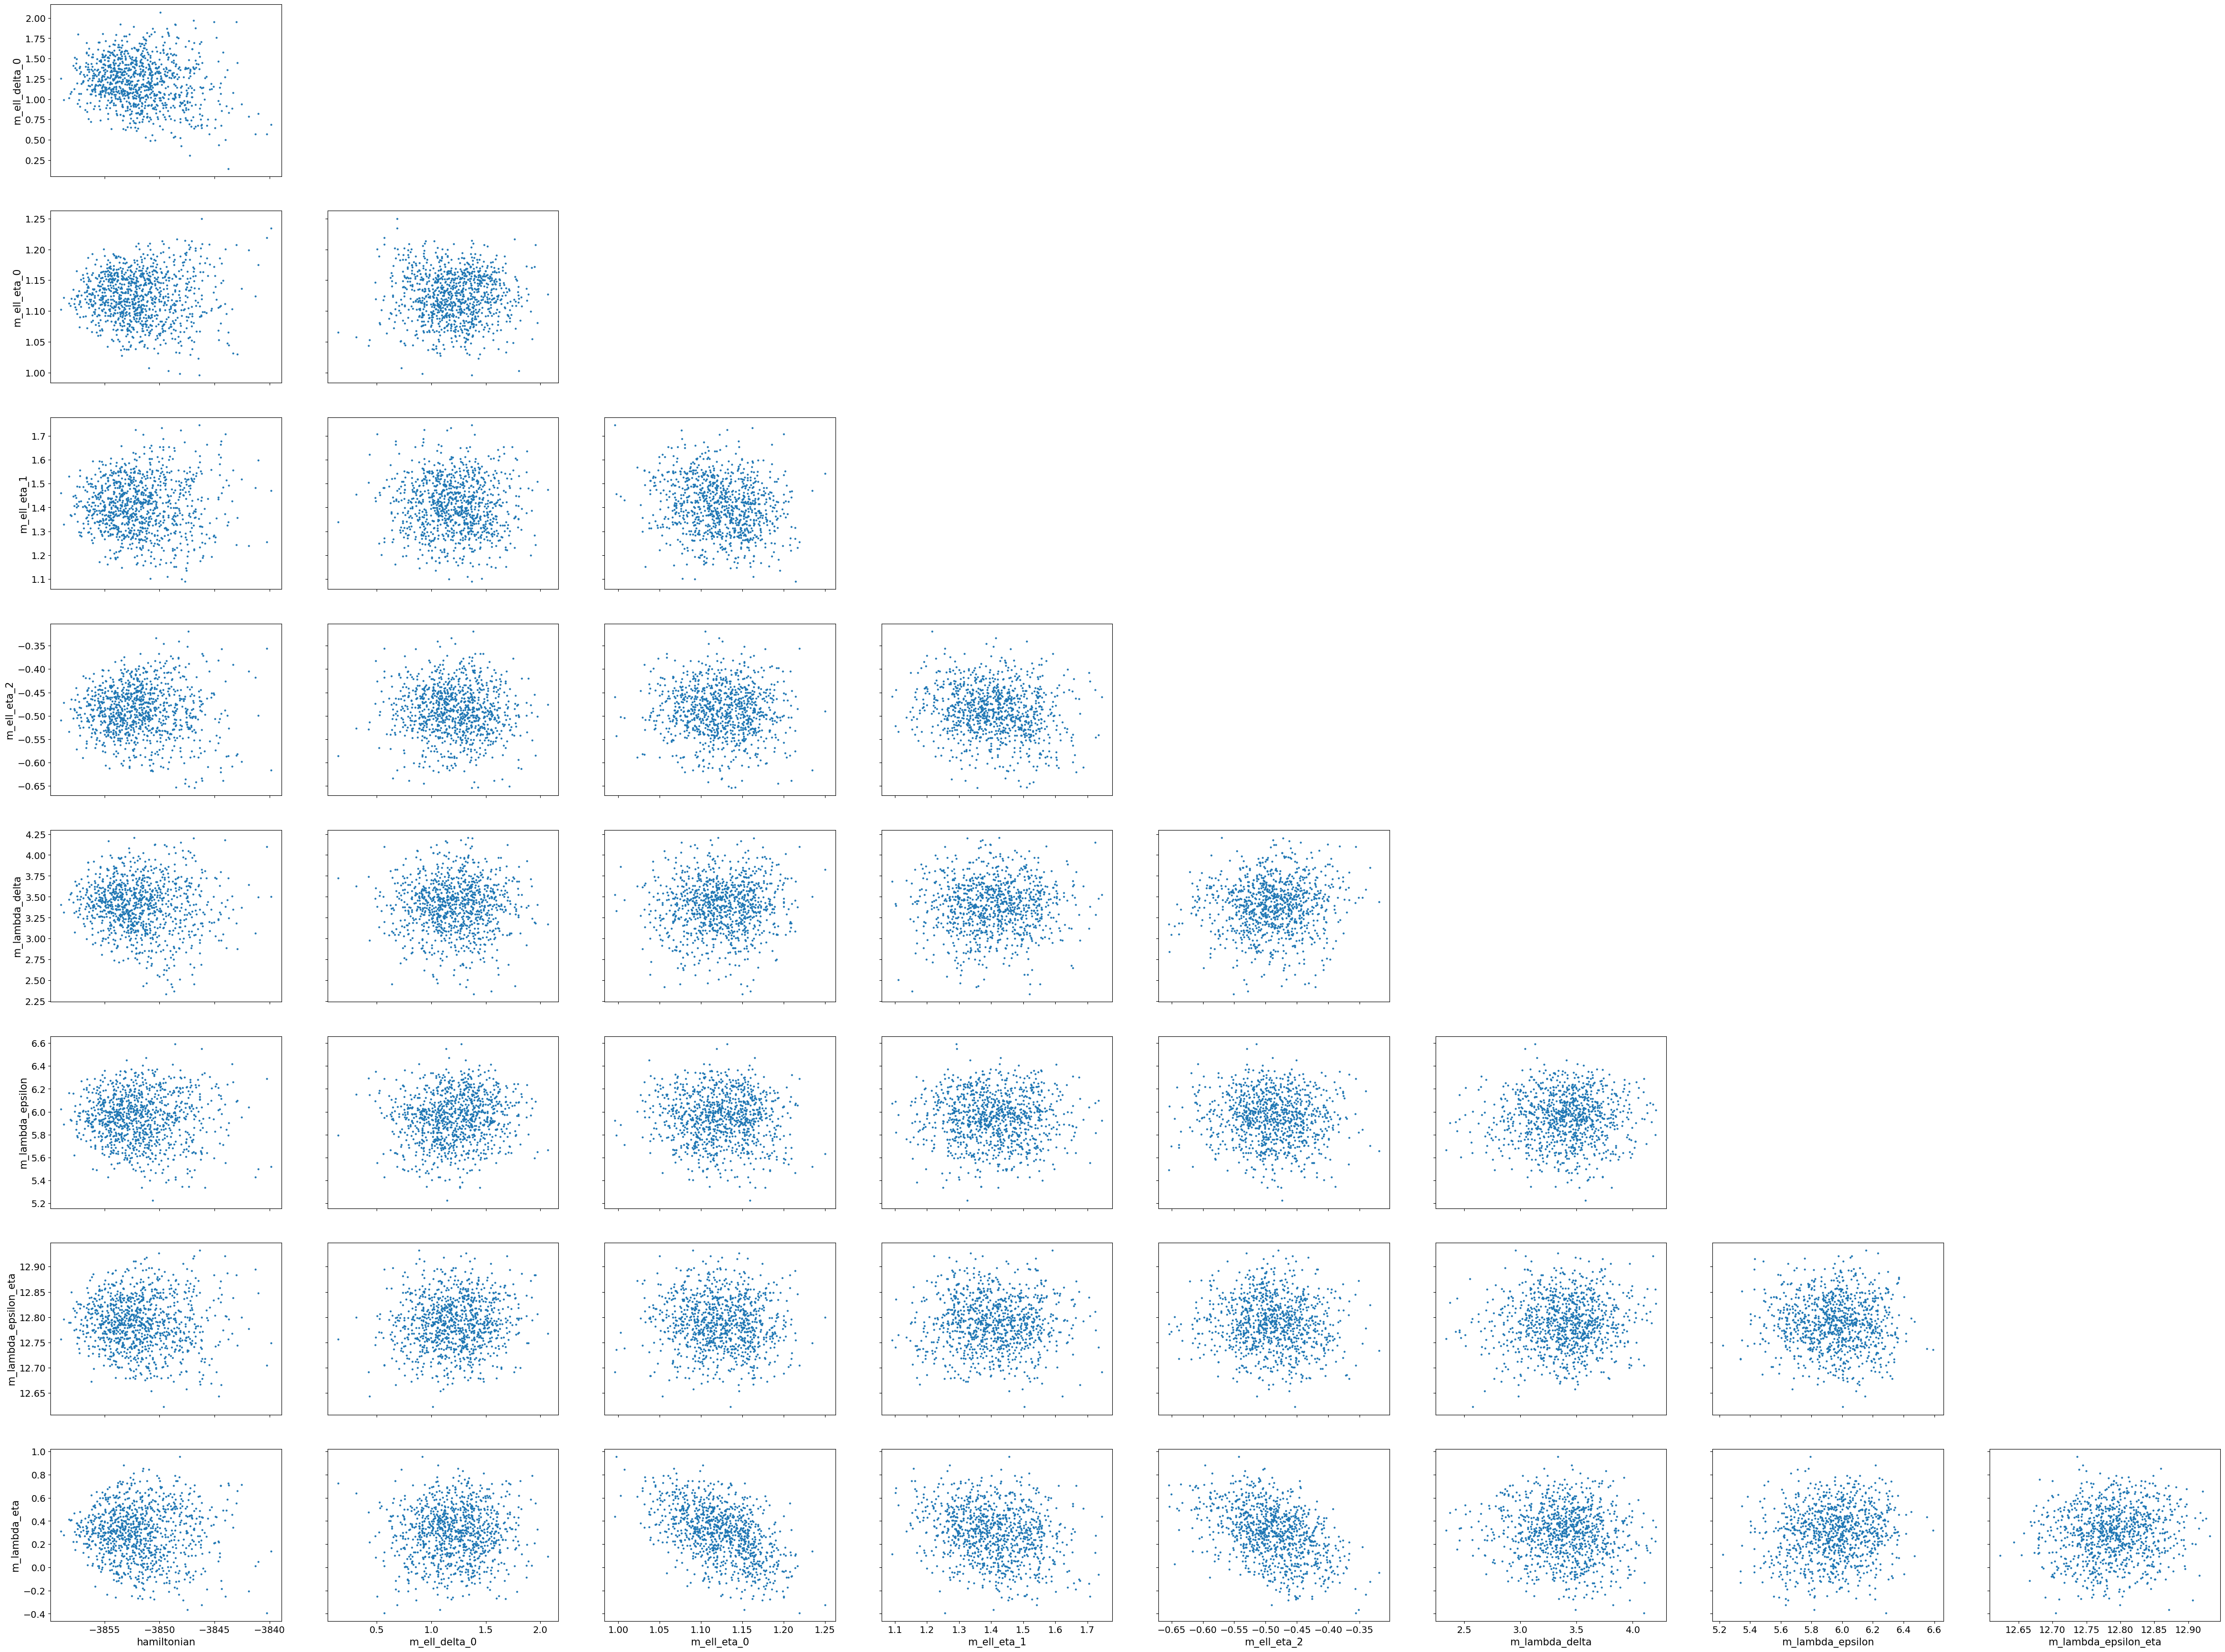

In [12]:
_ = arviz.plot_pair(traces)

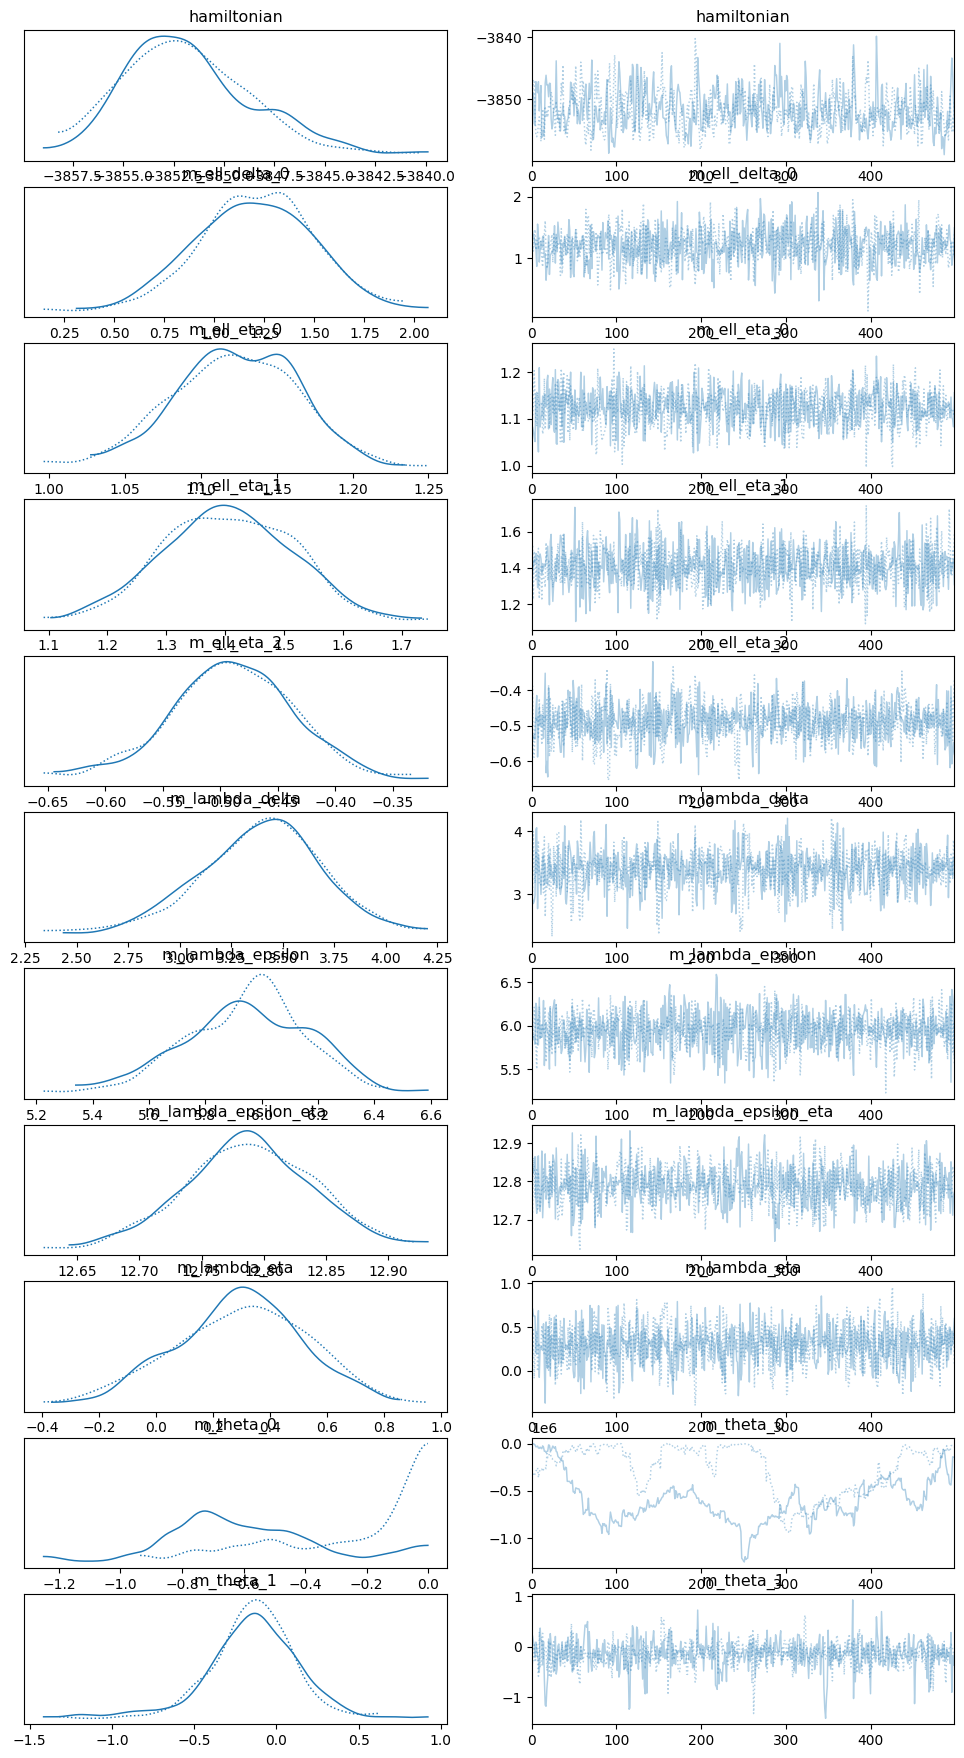

In [13]:
_ = arviz.plot_trace(traces)

In [14]:
for var, trace in traces.items():
    print(var, ": ", np.mean(trace[0]), '±', np.std(trace[0]))

m_theta_0 :  -595490.5673215477 ± 244511.64731356953
m_theta_1 :  -0.15015920270988364 ± 0.29910621531826564
m_ell_eta_0 :  1.124915247500629 ± 0.03765595538047137
m_ell_eta_1 :  1.404316178674348 ± 0.11265862248217723
m_ell_eta_2 :  -0.48994431917602366 ± 0.05326975645531534
m_ell_delta_0 :  1.1967778986064332 ± 0.29128090832043046
m_lambda_eta :  0.28881847257910137 ± 0.21648214079733422
m_lambda_delta :  3.3875571556668214 ± 0.301592973650447
m_lambda_epsilon :  5.9450616414527895 ± 0.2260193455995608
m_lambda_epsilon_eta :  12.787550972707647 ± 0.050768979554692374
hamiltonian :  -3851.677791912025 ± 3.1740417979971745


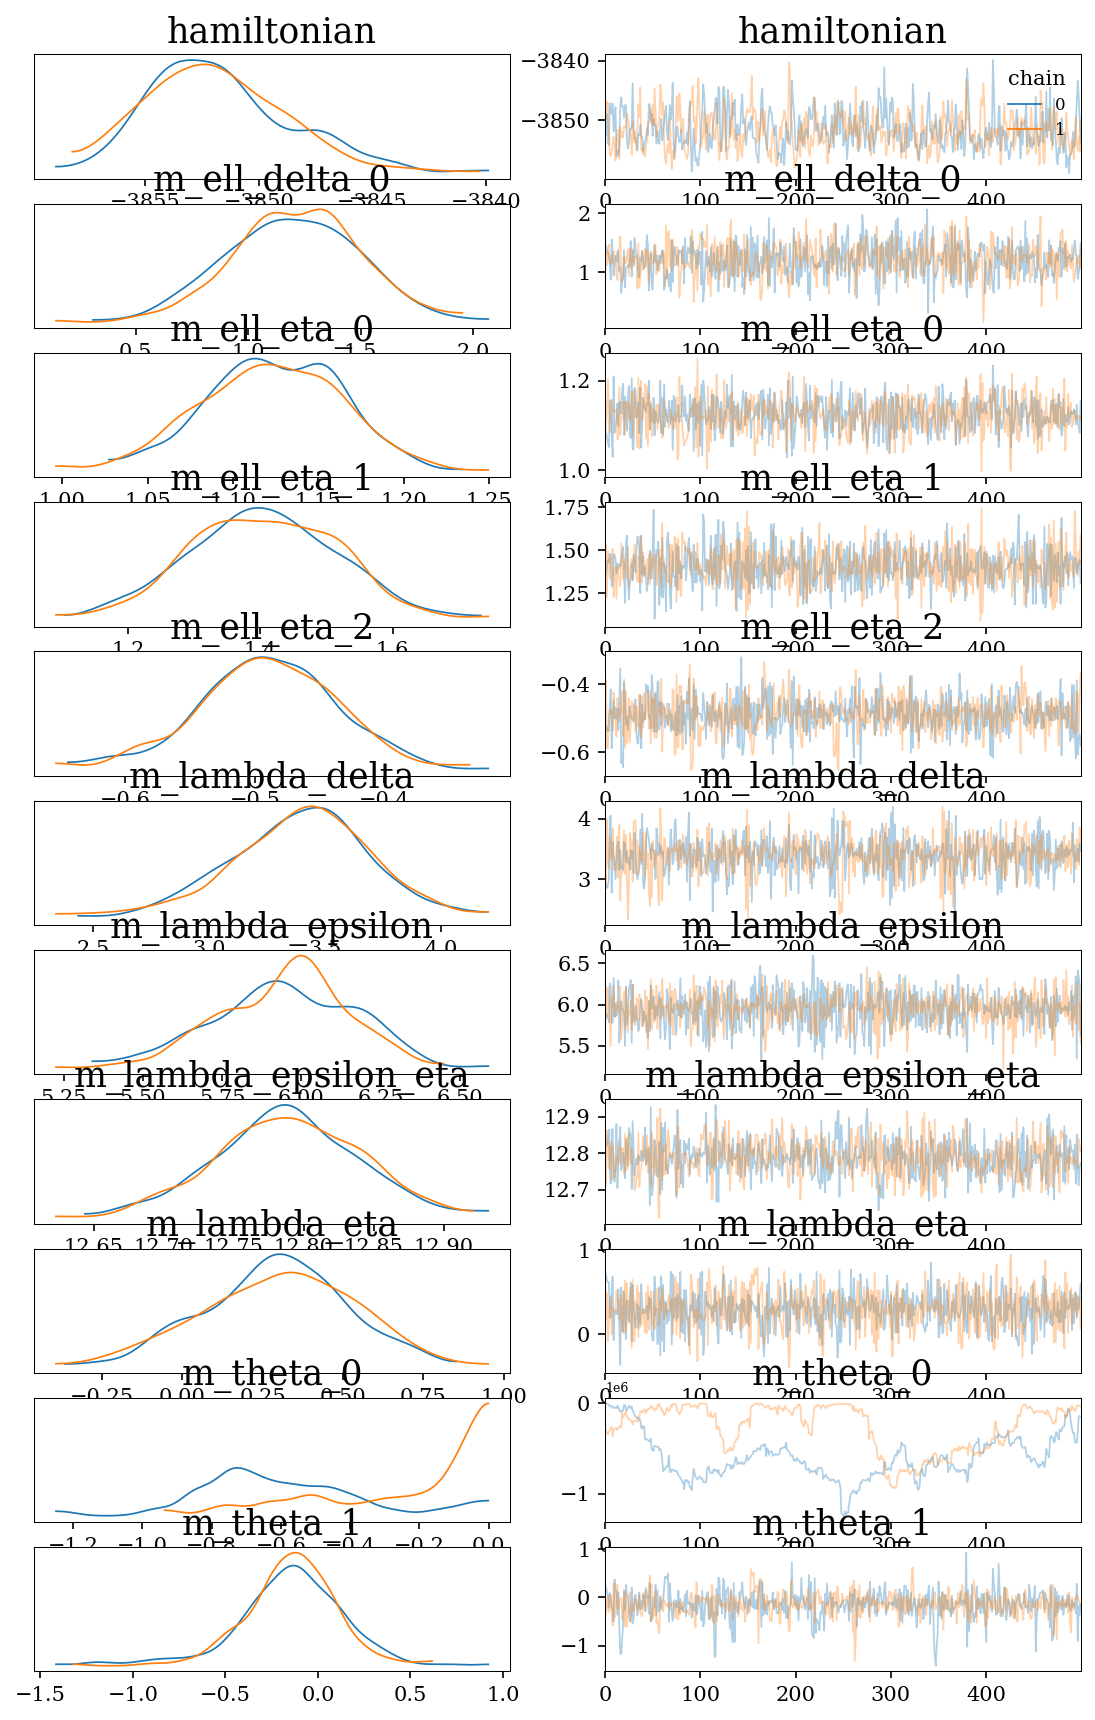

In [15]:
with plt.style.context(plot_style):
    arviz.plot_trace(
        traces,
        # var_names=["σ", "ϵ", "γ", "β", "x_0"],
        figsize=(9, 2 * (7)),
        legend=True,
        compact=False,
    )


## Analyse the transformed MCMC chains

In [16]:
traces_transformed = {}
for var, trace in traces.items():
    if var == 'hamiltonian':
        continue
    var_name = var.split('m_')[1]
    if var_name.startswith('theta'):
        theta_num = int(var_name.split('_')[1])
        traces_transformed[var_name] = mapRto01(trace[0])*(tmax[theta_num]-tmin[theta_num]) + tmin[theta_num]
    elif var_name.startswith('ell'):
        traces_transformed[var_name] = mapRto0inf(trace[0])
    elif var_name.startswith('lambda'):
        traces_transformed[var_name] = mapRto0inf(trace[0])

params_transformed = {}
for var, trace in traces_transformed.items():
    params_transformed[var] = np.mean(trace)
    print(var, ": ", np.mean(trace), '±', np.std(trace))

theta_0 :  0.44421374797821045 ± 0.0
theta_1 :  -2.909862726308035 ± 0.1377124773081287
ell_eta_0 :  3.08213787083733 ± 0.11590373721421454
ell_eta_1 :  4.098733616488295 ± 0.46477208942404735
ell_eta_2 :  0.6135284280316599 ± 0.03259723375135447
ell_delta_0 :  3.4523329993185707 ± 1.0184731447583304
lambda_eta :  1.3661758172402454 ± 0.29415719089353015
lambda_delta :  30.949503455492508 ± 9.33502073163282
lambda_epsilon :  391.6089546308319 ± 87.58550686304095
lambda_epsilon_eta :  358197.79229809117 ± 18215.65322448505


In [17]:
arviz.summary(traces_transformed)

Shape validation failed: input_shape: (1, 500), minimum_shape: (chains=2, draws=4)
/home/matt/projects/mici-help/.venv/lib/python3.12/site-packages/arviz/stats/diagnostics.py:991: RuntimeWarning: invalid value encountered in scalar divide
  varsd = varvar / evar / 4


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
ell_delta_0,3.452,1.019,1.747,5.281,0.054,0.048,419.0,302.0,NaN
ell_eta_0,3.082,0.116,2.857,3.292,0.004,0.005,686.0,436.0,NaN
ell_eta_1,4.099,0.465,3.279,4.980,0.016,0.020,922.0,369.0,NaN
ell_eta_2,0.614,0.033,0.555,0.682,0.001,0.002,650.0,259.0,NaN
lambda_delta,30.950,9.344,14.566,46.934,0.339,0.536,734.0,360.0,NaN
lambda_epsilon,391.609,87.673,227.365,540.013,3.214,5.215,766.0,340.0,NaN
lambda_epsilon_eta,358197.792,18233.896,320791.017,389674.834,852.717,867.086,449.0,300.0,NaN
lambda_eta,1.366,0.294,0.870,1.966,0.011,0.012,652.0,318.0,NaN
theta_0,0.444,0.000,0.444,0.444,0.000,NaN,500.0,500.0,NaN
theta_1,-2.910,0.138,-3.182,-2.657,0.008,0.010,403.0,191.0,NaN


**NOTE**: The red priors below are probably different from the priors used above. Please ignore these red priors.

/home/matt/projects/mici-help/.venv/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/traceplot.py:218: UserWarning: A valid var_name should be provided, found {'theta'} expected from {'theta_1', 'lambda_eta', 'lambda_epsilon_eta', 'ell_eta_1', 'ell_eta_2', 'theta_0', 'lambda_epsilon', 'ell_delta_0', 'lambda_delta', 'ell_eta_0'}
  warnings.warn(
/home/matt/projects/mici-help/.venv/lib/python3.12/site-packages/arviz/stats/density_utils.py:488: UserWarning: Your data appears to have a single value or no finite values
  warnings.warn("Your data appears to have a single value or no finite values")


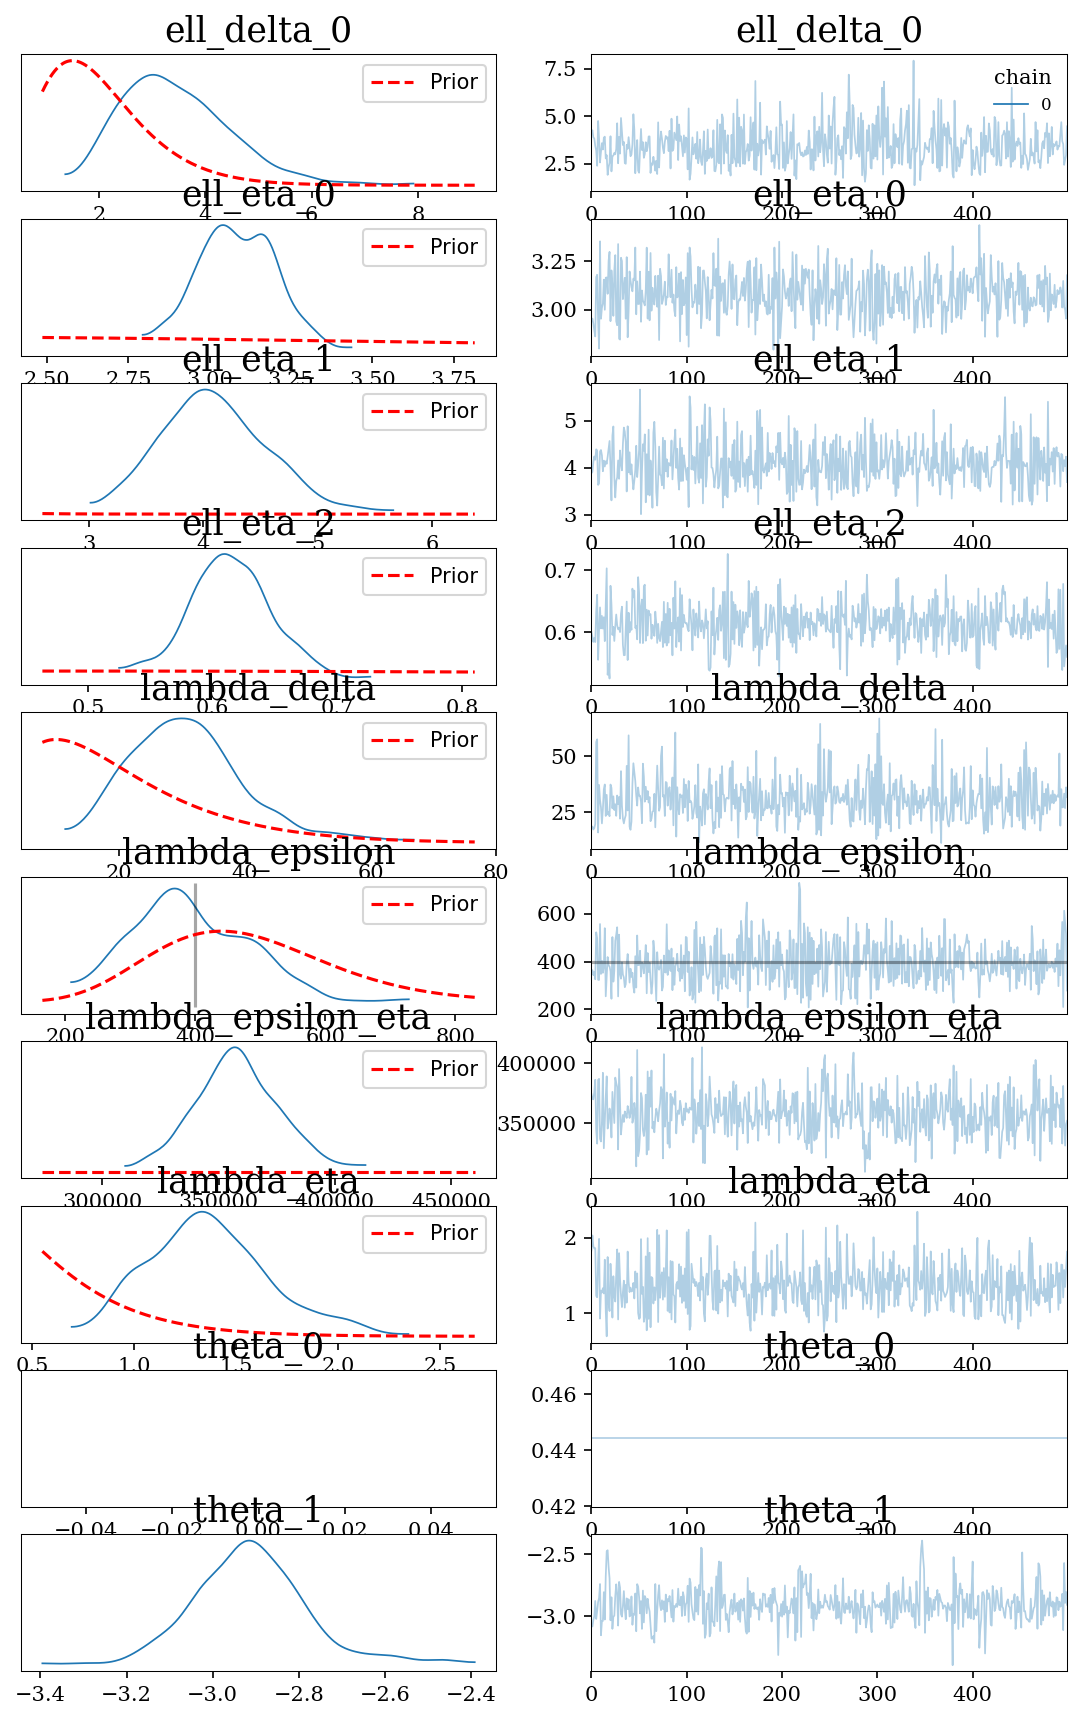

In [18]:
priors = {
    # 'ell_delta_0': [4, 1],
    'ell_delta_0': [4, 2],
    'ell_delta_1': [4, 2],
    'ell_eta_0': [4, 1.4],
    'ell_eta_1': [2, 3.5],
    'ell_eta_2': [2, 2],
    'ell_eta_3': [2, 2],
    # 'lambda_delta': [10, 0.3],
    'lambda_delta': [2, 0.1],
    'lambda_epsilon': [12, 0.025],
    'lambda_epsilon_eta': [10, 0.001],
    'lambda_eta': [2, 4],
}

with plt.style.context(plot_style):
    axes = arviz.plot_trace(
        traces_transformed,
        figsize=(9, 2 * (7)),
        legend=True,
        compact=False,
        lines=(
            ('theta', {}, 0.4),
            ('lambda_epsilon', {}, 1/0.05**2)    
        )
    )
for i in range(axes.shape[0]):
    left, right = axes[i, 0].get_xlim()
    left, right = left*0.9, right*1.1
    x = np.linspace(left, right, 1000)
    title = axes[i, 0].get_title()
    if title in priors:
        alpha, beta = priors[title]
        pdf = gamma.pdf(x, a=alpha, scale=1/beta)
        axes[i, 0].plot(x, pdf, color='red', linestyle='--', label='Prior')
        axes[i, 0].legend()
plt.show()